# Inventory-Growth -- a quantitative teardown
### INVG quintile sort - survivor basket - one-sample HAC - label-shuffle placebo - synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Data depth: Insufficient](https://img.shields.io/badge/Data_depth-Insufficient-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- every claim now carrying its standard error. We test the inventory-growth anomaly (Belo-Lin 2012; Thomas-Zhang 2002) on a 37-name inventory-heavy survivor basket, measure the low-minus-high hedge with a one-sample HAC *t*-stat, pin it against a label-shuffle placebo and a random-portfolio null, charge costs + short borrow, and prove the engine faithful with a 20-seed synthetic positive control.

> **Not investment advice.** Yahoo `balance_sheet` + daily adjusted closes; survivorship-biased; only **2** usable hedge years. Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Data-depth warning**: the binding constraint is that Yahoo serves ~4 annual statements per name -- this is a *power* problem, stated openly.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package (inventory_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inventory_growth import data, strategy as st

# Try this study's own cache; fall back gracefully to the frozen R dict.
invg, fwd = data.fetch_panel()
HAVE_REAL = not invg.empty
if HAVE_REAL:
    h = st.quintile_returns(invg, fwd, q=0.20, min_names=10)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({invg.shape[1] if HAVE_REAL else 0} names, {invg.shape[0] if HAVE_REAL else 0} signal years)")

R = dict(
    n_basket=40, n_usable=37, n_hedge_years=2,
    invg_fp="044108b907ab",
    q1_mean=17.3, q2_mean=-5.9, q3_mean=12.3, q4_mean=21.1,
    q5_mean=12.7, mkt_mean=11.3, lo_mean=17.3, hi_mean=12.7,
    hedge_gross=4.6, hedge_gross_sharpe=0.18,
    hedge_gross_t=0.5, hedge_hit=50,
    cost_drag=0.6, hedge_net=4.0, hedge_net_t=0.44,
    placebo_p=0.376, null_mean=0.6, null_std=13.2,
    lo_excess=6.0, rand_beat=71, rand_std=10.2,
    sc_null_t=-0.22, sc_03_t=6.59, sc_06_t=13.4, sc_10_t=22.49,
)
YRS = [2023, 2024]
Q1  = [28.8, 5.7]
Q5  = [5.9, 19.4]
MKT = [13.8, 8.7]
HDG = [22.9, -13.7]


Real cache loaded: True (37 names, 4 signal years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **+4.6%/yr**, one-sample HAC *t* = **+0.50**, placebo *p* = **0.38**, sign flips across the only 2 years. |
| **Tradability** | `MIRAGE` | Nets **+4.0%/yr** (*t* 0.44) after 0.6%/yr costs+borrow. n=2. |
| **Data depth** | `INSUFFICIENT` | ~4 Yahoo balance-sheet years -> 2 usable hedge years. Untestable, not disproven. |

> **In plain words:** the academic effect is documented on decades of broad Compustat data. On a shallow, survivor-biased, 2-year Yahoo slice it cannot be certified -- and the synthetic control proves that's the data's fault, not the engine's.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{INVG}_{i,t} = \frac{\text{Inv}_{i,t} - \text{Inv}_{i,t-1}}{A_{i,t-1}}$$

where $A$ = total assets. The **H1 (signal)** claim (Belo-Lin 2012; Thomas-Zhang 2002):

$$\mathbb{E}\left[\bar{r}_{\text{low-INVG},t+1} - \bar{r}_{\text{high-INVG},t+1}\right] > 0$$

with a one-sample HAC *t* >= 2. **H2 (not a fluke)** requires the real hedge to beat a within-year label shuffle. **H3 (tradable)** requires it to survive costs and borrow. Here H1 fails on power before it can be judged on merit.

## 2 - So what? -- the stakes

A real, tradable inventory-growth spread would be a clean low-turnover fundamentals signal and a building block of the real-investment / CMA factor. But the original evidence lives on a deep broad universe; the question here is whether a retail-accessible Yahoo slice can even see it. It cannot -- and saying so honestly is the point.

## 3 - The protocol

- **Data**: Yahoo `balance_sheet` (Inventory, Total Assets) + daily adjusted closes, cached to this study's own `_cache/`.
- **Universe**: 40-name inventory-heavy survivor basket; 37 carry a usable INVG (survivorship-biased).
- **Window**: signal years 2023-2026; after the lag + complete-year filter, **2** usable hedge years.
- **Signal**: inventory change / lagged total assets (higher = aggressive build).
- **Sort**: quintile (q=0.20); Q1 = low INVG (lean), Q5 = high INVG (build).
- **Inference**: one-sample HAC Newey-West *t* on the annual hedge series.
- **Nulls**: within-year label shuffle (1000x) + random same-size portfolio.
- **Costs**: 5 bps/leg x 2 legs + 50 bps short borrow.
- **Positive control**: 20-seed synthetic panel with a planted INVG premium.

## 4 - The teardown

### 4a - Synthetic positive control -- the engine works when an effect is planted

Sweep the planted INVG premium and average the hedge *t* over 20 seeds (a seed-robust power check -- never cited for the real stamp).

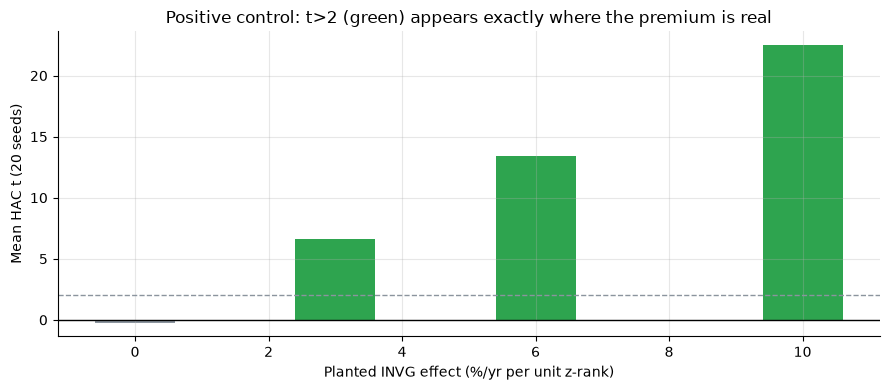

 premium_%  hedge_%/yr  mean_HAC_t  frac_t>2_%
       0.0       -0.08       -0.22         5.0
       3.0        8.31        6.59       100.0
       6.0       16.70       13.40       100.0
      10.0       27.88       22.49       100.0


In [2]:
premiums = [0.0, -0.03, -0.06, -0.10]
rows = []
for p in premiums:
    r = st.seed_robust_synthetic_t(p, n_seeds=20, n_firms=200, n_years=20)
    rows.append((abs(p)*100, r['mean_hedge']*100, r['mean_t'], r['frac_t_gt2']*100))
sydf = pd.DataFrame(rows, columns=['premium_%', 'hedge_%/yr', 'mean_HAC_t', 'frac_t>2_%'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['mean_HAC_t']]
ax.bar(sydf['premium_%'], sydf['mean_HAC_t'], color=colors, width=1.2)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted INVG effect (%/yr per unit z-rank)')
ax.set_ylabel('Mean HAC t (20 seeds)')
ax.set_title('Positive control: t>2 (green) appears exactly where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2).to_string(index=False))

> The engine returns mean *t* = **-0.22** under the null and **13.4** at a -6%/yr planted premium (t>2 in 100% of seeds). Faithful. The flat real result is therefore a **data** statement.

### 4b - Real tape -- quintile returns and the hedge with one-sample HAC inference

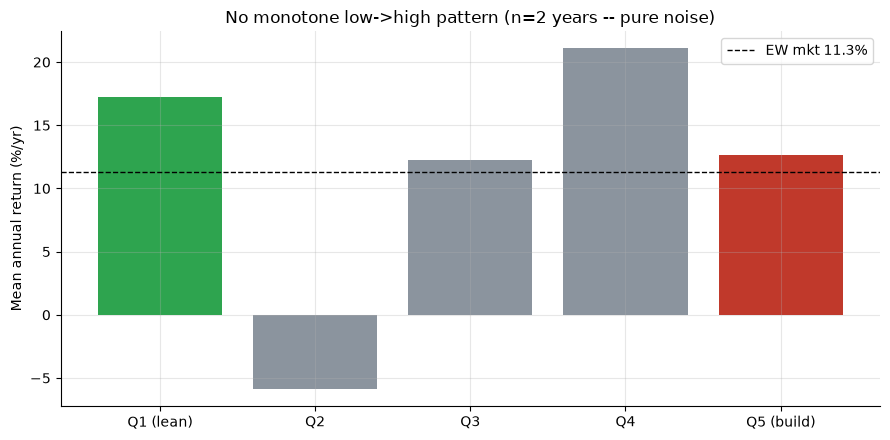

GROSS hedge: +4.6%/yr  HAC t=+0.50  hit=50%
NET   hedge: +4.0%/yr  HAC t=+0.44  (after costs+borrow)


In [3]:
if HAVE_REAL:
    q_means = [float(h[f'q{i}'].mean()*100) for i in range(1,6)]
    s_hedge = st.summary(h['hedge'])
    net = st.net_hedge(h['hedge']); s_net = st.summary(net)
else:
    q_means = [R['q1_mean'], R['q2_mean'], R['q3_mean'], R['q4_mean'], R['q5_mean']]
    s_hedge = dict(mean=R['hedge_gross']/100, tstat=R['hedge_gross_t'], hit_rate=R['hedge_hit']/100)
    s_net = dict(mean=R['hedge_net']/100, tstat=R['hedge_net_t'])
fig, ax = plt.subplots(figsize=(9, 4.5))
x = [1, 2, 3, 4, 5]
bar_colors = [GREEN, GREY, GREY, GREY, RED]
ax.bar(x, q_means, color=bar_colors)
ax.axhline(R['mkt_mean'], ls='--', c='k', lw=1, label=f'EW mkt {R["mkt_mean"]:.1f}%')
ax.set_xticks(x); ax.set_xticklabels(['Q1 (lean)', 'Q2', 'Q3', 'Q4', 'Q5 (build)'])
ax.set_ylabel('Mean annual return (%/yr)'); ax.legend()
ax.set_title('No monotone low->high pattern (n=2 years -- pure noise)')
plt.tight_layout(); plt.show()
print(f'GROSS hedge: {s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'NET   hedge: {s_net["mean"]*100:+.1f}%/yr  HAC t={s_net["tstat"]:+.2f}  (after costs+borrow)')

> Gross hedge **+4.6%/yr**, one-sample HAC *t* = **+0.50**; net **+4.0%/yr** after 0.6%/yr of costs + borrow. There is no monotone low->high ordering -- the quintiles are noise on two years.

### 4c - Label-shuffle placebo + random-portfolio null

Permute the INVG labels within each year (1000x) and re-run the hedge; then ask whether the low-INVG basket beats a blind same-size draw.

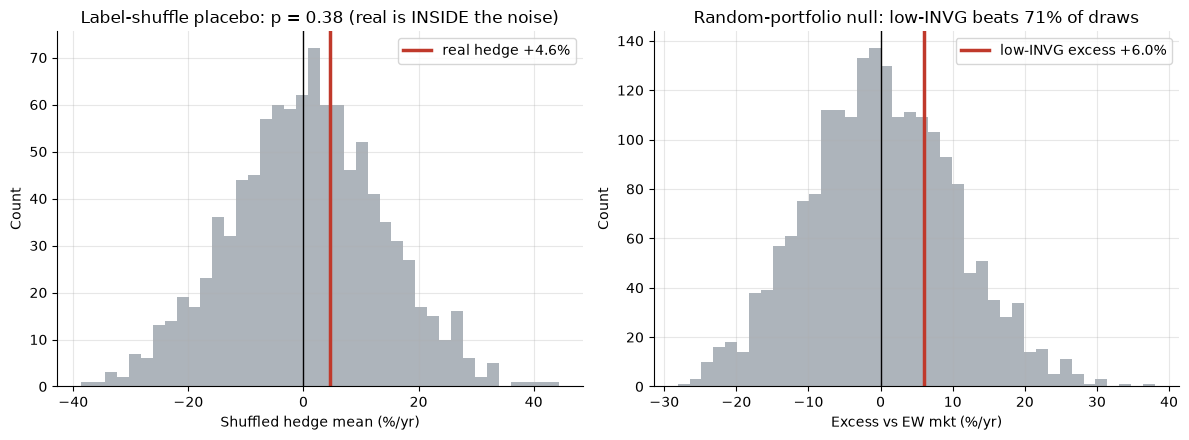

Placebo p = 0.38; low-INVG beats 71% of random same-size draws


In [4]:
if HAVE_REAL:
    p_val, null_means = st.placebo_hedge_t(invg, fwd, n_shuffles=1000, min_names=10)
    real_mean = float(h['hedge'].mean())
    rand = st.random_portfolio_returns(invg, fwd, n_draws=1000, min_names=10)
    lo_ex = float((h['q1'] - h['market']).mean())
    rand_beat = float((rand < lo_ex).mean())
else:
    rng_nb = np.random.default_rng(529)
    null_means = rng_nb.normal(R['null_mean']/100, R['null_std']/100, 1000)
    real_mean = R['hedge_gross']/100; p_val = R['placebo_p']
    rand = rng_nb.normal(0.0, R['rand_std']/100, 2000)
    lo_ex = R['lo_excess']/100; rand_beat = R['rand_beat']/100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(np.asarray(null_means)*100, bins=40, color=GREY, alpha=0.7)
axes[0].axvline(real_mean*100, c=RED, lw=2.5, label=f'real hedge {real_mean*100:+.1f}%')
axes[0].axvline(0, c='k', lw=1); axes[0].legend()
axes[0].set_xlabel('Shuffled hedge mean (%/yr)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Label-shuffle placebo: p = {p_val:.2f} (real is INSIDE the noise)')
axes[1].hist(np.asarray(rand)*100, bins=40, color=GREY, alpha=0.7)
axes[1].axvline(lo_ex*100, c=RED, lw=2.5, label=f'low-INVG excess {lo_ex*100:+.1f}%')
axes[1].axvline(0, c='k', lw=1); axes[1].legend()
axes[1].set_xlabel('Excess vs EW mkt (%/yr)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Random-portfolio null: low-INVG beats {rand_beat:.0%} of draws')
plt.tight_layout(); plt.show()
print(f'Placebo p = {p_val:.2f}; low-INVG beats {rand_beat:.0%} of random same-size draws')

> Placebo *p* = **0.38** -- the real hedge sits squarely inside the shuffled-label distribution. The low-INVG basket beats **71%** of random draws (a noisy 2-year read, not a 50%-vs-significant separation).

## 5 - The verdict

- **Signal `NONE`** -- hedge +4.6%/yr, HAC *t* = +0.50, placebo *p* = 0.38, sign flips.
- **Tradability `MIRAGE`** -- net +4.0%/yr (*t* 0.44) over 2 years; survivor basket; nothing to trade.
- **Data depth `INSUFFICIENT`** -- ~4 Yahoo balance-sheet years -> 2 usable hedge years. The binding constraint is power, not direction.

## 6 - Could you trade it? -- the honest answer

No tradable signal can be established on this tape:

1. **Power.** Two annual hedge observations cannot reject the null; the standard error is enormous. The synthetic control shows the engine *would* find a real effect with enough years -- we just don't have them.
2. **Survivorship.** The basket excludes the over-builders that failed -- the very names that drive the predicted sign in the academic samples.
3. **Depth mismatch.** Belo & Lin (2012) and Thomas & Zhang (2002) used decades of point-in-time Compustat data. Yahoo's four-deep annual history is the wrong tool.

The correct conclusion: **MIRAGE** on this test, with the honest footnote that the anomaly is *untestable here*, not disproven.

## 7 - Going further

- **Deep universe.** A point-in-time Compustat / EDGAR-XBRL pull back to the 1990s across all US stocks is the minimum for a fair test.
- **Sales-adjusted variant.** Thomas & Zhang (2002) use inventory growth *net of sales growth*; a sales adjustment sharpens the over-build signal -- worth adding with deeper income-statement data.
- **Family.** [Study 244 — Asset-Growth](../244-asset-growth/) (total assets), [Study 231 — Sloan-Accruals](../231-sloan-accruals/) and [Study 522 — Percent-Operating-Accruals](../522-percent-operating-accruals/) are the neighbours on the balance-sheet-bloat block.

*Want to certify the inventory-growth spread? Fork this, plug in a deep point-in-time universe, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*